# Prédiction de WMI — pipeline propre

## Imports

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, RepeatedKFold, KFold, cross_validate,
    learning_curve, GridSearchCV,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.precision", 3)

## Chargement des données

In [215]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()
raw_df.shape

(65, 18)

## Split train / test — AVANT tout pretraitement

Règle d'or : **aucune information du test (y compris la cible) ne doit jamais entrer dans
le fit d'un encodeur, d'un imputer, d'un scaler ou d'un modèle.**
On sépare donc X (prédicteurs uniquement, sans la cible) et y (la cible), puis on fait le split.

In [216]:
TARGET_COLUMN = "WMI"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")

Cible : WMI
Train : 58 patients | Test : 7 patients


## Encodage de `Hipp`

L'encodeur est **fit uniquement sur `X_train`**, puis simplement appliqué (`transform`) sur
`X_test` avec `handle_unknown="ignore"` au cas où une catégorie rare n'apparaîtrait que dans le test.

In [217]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
12,-125.3,92.5,-21.6,-54.0,11.2,NaN,NaN,1.0,0.0,0.0
64,-48.4,33.7,-53.2,NaN,NaN,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,-73.1,NaN,NaN,1,81/81,0.0,0.0,1.0
33,0.0,168.0,-74.2,-11.0,0.0,98%,80/77,0.0,1.0,0.0
9,-105.0,79.3,-18.8,NaN,NaN,0.94,68/43,1.0,0.0,0.0


## Nettoyage des données (colonnes trop incomplètes)

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — sans jamais regarder les valeurs du test pour décider quoi supprimer.

In [218]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         60.345
OB         58.621
LRC        36.207
N400       36.207
P600        3.448
P300        3.448
LNC         3.448
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

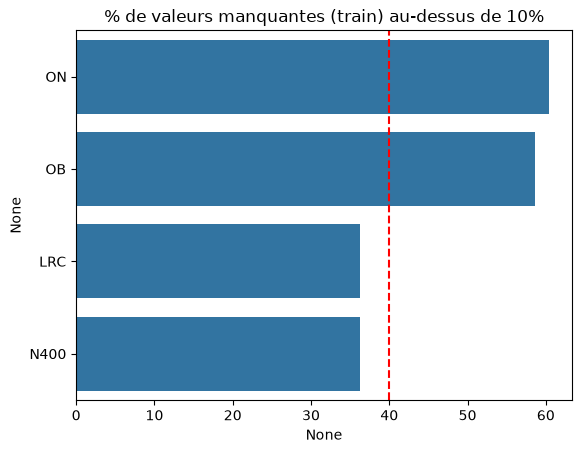

In [219]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")

In [220]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape

Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((58, 8), (7, 8))

### Retirer les lignes où la cible (`WMI`) est manquante

On n'impute jamais la variable à prédire : impossible d'entraîner ou d'évaluer sur une ligne
dont on ne connaît pas la vraie réponse. On filtre donc train et test séparément.

In [221]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train = X_train.loc[train_mask.index[train_mask]]

y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train.shape[0]} patients | Test final : {X_test.shape[0]} patients")

Lignes retirées (train, WMI manquant) : 2
Lignes retirées (test, WMI manquant)  : 0
Lignes retirées (train, WMI manquant) : 2
Lignes retirées (test, WMI manquant)  : 0
Train final : 56 patients | Test final : 7 patients


## Plot représentation train

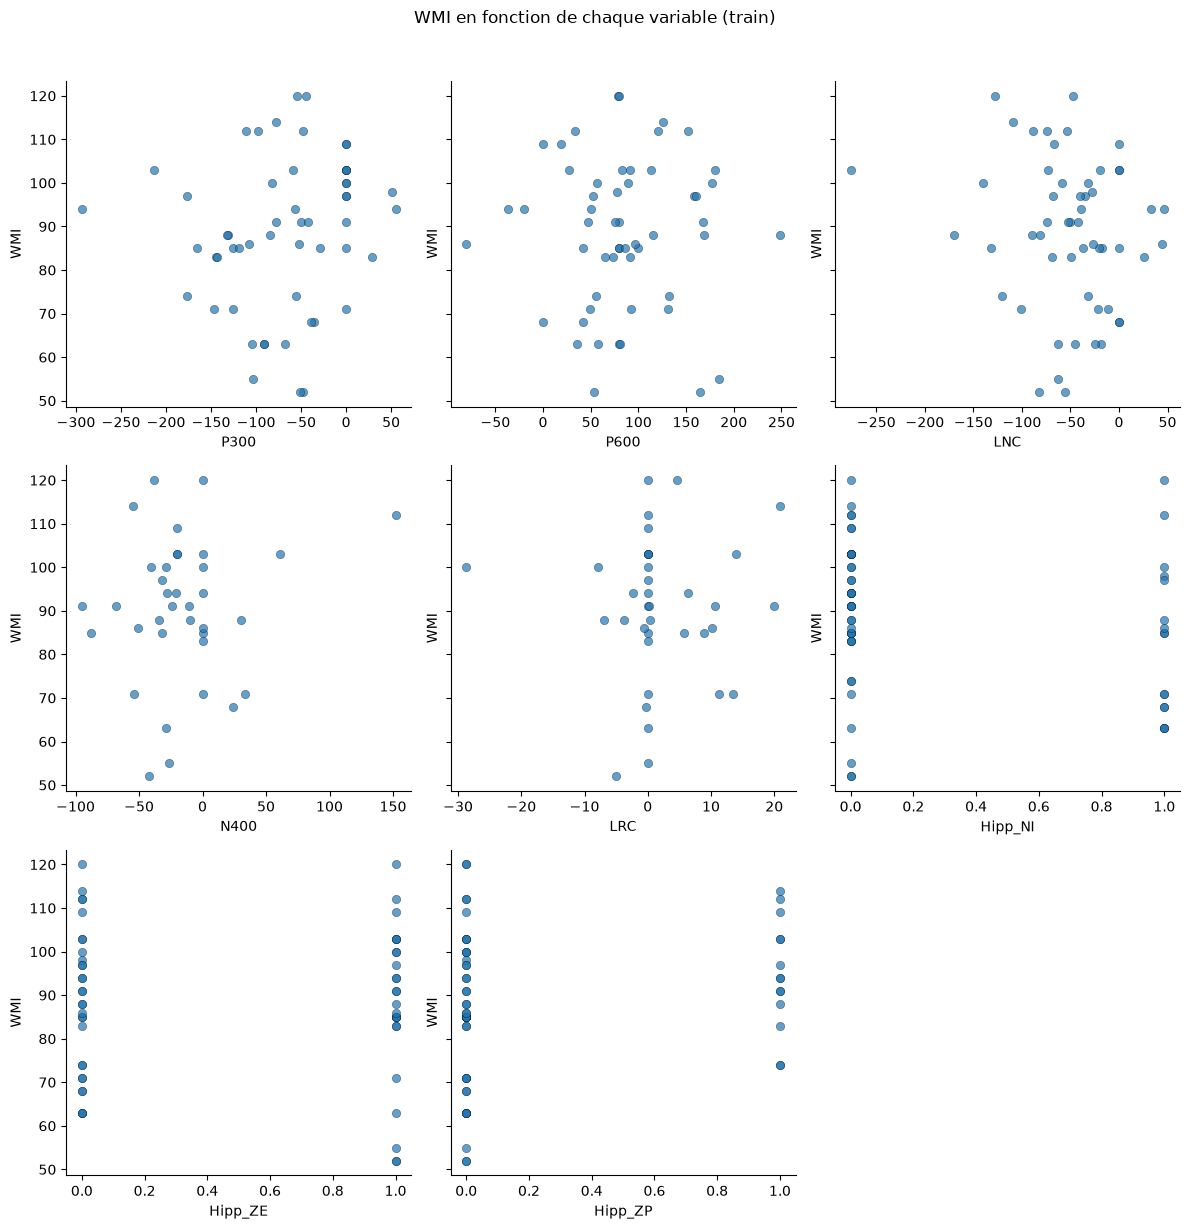

In [222]:
n_cols = 3
n_rows = int(np.ceil(len(X_train.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, X_train.columns):
    ax.scatter(X_train[feature], y_train, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("WMI")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(X_train.columns):]:
    ax.axis("off")

fig.suptitle("WMI en fonction de chaque variable (train)", y=1.02)
plt.tight_layout()
plt.show()

## Discrétisation WMI

In [223]:
# y_train / y_test sont des Series (colonne WMI) : on les convertit en DataFrame
y_train_df = y_train.to_frame(name="WMI")
y_test_df = y_test.to_frame(name="WMI")

# Bornes calculées UNIQUEMENT sur le train (jamais sur le test, pour éviter une fuite)
bin_edges = [
    y_train_df["WMI"].min() - 1,
    y_train_df["WMI"].quantile(1 / 3),
    y_train_df["WMI"].quantile(2 / 3),
    y_train_df["WMI"].max() + 1,
]
labels = ["bad", "medium", "good"]

y_train_df["WMI_Category"] = pd.cut(x=y_train_df["WMI"], bins=bin_edges, labels=labels)

# On applique les mêmes bornes au test (pas de recalcul sur le test !)
y_test_df["WMI_Category"] = pd.cut(x=y_test_df["WMI"], bins=bin_edges, labels=labels)

## Réduction de dimensions : ACP

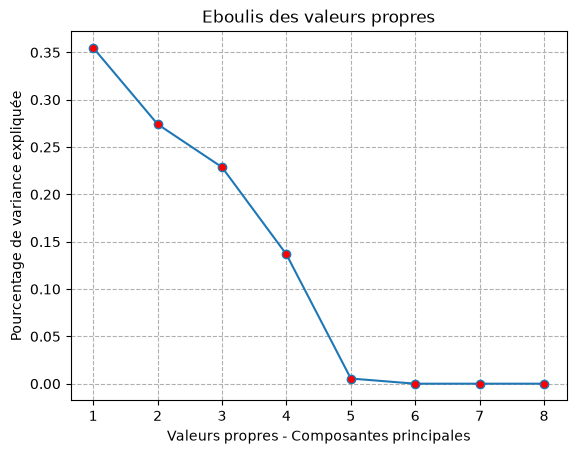

In [224]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
# calculer la part de variance expliquée directement depuis les scores PCA si pca n'est pas défini
explained_variance_ratio = np.var(X_train, axis=0) / np.sum(np.var(X_train, axis=0))

plt.plot(range(1, X_train.shape[1] + 1), explained_variance_ratio, marker="o", markerfacecolor="r")
plt.xlabel('Valeurs propres - Composantes principales'); 
plt.xticks(range(1, X_train.shape[1] + 1))
plt.ylabel('Pourcentage de variance expliquée');
plt.grid(linestyle='--')
plt.title("Eboulis des valeurs propres");
plt.xlabel('Valeurs propres - Composantes principales'); 
plt.xticks(range(1,X_train.shape[1]+1))
plt.ylabel('Pourcentage de variance expliquée');
plt.grid(linestyle='--')
plt.title("Eboulis des valeurs propres");

In [225]:
print(explained_variance_ratio.iloc[:4].sum())

0.9944726174832985


## Comparaison des modèles

Le `StandardScaler` reste dans la `Pipeline` pour être re-fit à chaque pli de la CV.
Le test (`X_test_imputed`, `y_test`) reste intouché jusqu'à l'évaluation finale.

In [226]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import KNNImputer
import warnings; warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ==========================
# Données
# ==========================

X = X_train
y = y_train_df["WMI_Category"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# même nombre de composantes que dans ton PCA actuel
n_components = X.shape[1]

# ==========================
# Grilles
# ==========================

param_grids = {

    "Logistic Regression": (
        LogisticRegression(max_iter=10000),
        {
            "model__C": [0.01,0.1,1,10],
            "model__penalty":["l2"],
        }
    ),

    "LDA": (
        LinearDiscriminantAnalysis(),
        {
            "model__solver":["svd","lsqr"],
        }
    ),

    "SVC": (
        SVC(),
        {
            "model__C":[0.1,1,10],
            "model__gamma":["scale","auto"],
            "model__kernel":["rbf","linear"],
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "model__n_estimators":[100,300],
            "model__max_depth":[None,3,5],
            "model__min_samples_leaf":[1,2,4],
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators":[100,200],
            "model__max_depth":[2,3],
            "model__learning_rate":[0.01,0.1],
        }
    ),
}

# ==========================
# Grid Search
# ==========================

models = {}
best_params_summary = []

for name, (estimator, grid) in param_grids.items():

    try:
        imputer
    except NameError:
        imputer = KNNImputer()

    pipeline = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", estimator),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X, y)

    # on conserve le pipeline complet
    models[name] = grid_search.best_estimator_

    best_params_summary.append({
        "Model": name,
        "Best F1_macro (CV)": round(grid_search.best_score_,3),
        "Best params": grid_search.best_params_,
    })

    print(
        f"{name} : meilleurs paramètres = "
        f"{grid_search.best_params_} "
        f"(F1_macro = {grid_search.best_score_:.3f})"
    )

best_params_df = (
    pd.DataFrame(best_params_summary)
    .sort_values("Best F1_macro (CV)", ascending=False)
)

display(best_params_df)

# ==========================
# Evaluation
# ==========================

def evaluate_model(name, pipeline, X, y, cv):

    scores = cross_validate(

        pipeline,

        X,

        y,

        cv=cv,

        scoring={
            "Accuracy":"accuracy",
            "F1_macro":"f1_macro",
            "Balanced_accuracy":"balanced_accuracy",
        },

        return_train_score=False,
    )

    return {

        "Model":name,

        "Accuracy_mean":np.mean(scores["test_Accuracy"]),

        "Accuracy_std":np.std(scores["test_Accuracy"]),

        "F1_macro_mean":np.mean(scores["test_F1_macro"]),

        "Balanced_accuracy_mean":np.mean(scores["test_Balanced_accuracy"]),
    }


results = [
    evaluate_model(name, pipeline, X, y, cv)
    for name, pipeline in models.items()
]

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Logistic Regression : meilleurs paramètres = {'model__C': 1, 'model__penalty': 'l2'} (F1_macro = 0.390)
LDA : meilleurs paramètres = {'model__solver': 'svd'} (F1_macro = 0.384)
SVC : meilleurs paramètres = {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'} (F1_macro = 0.448)


KeyboardInterrupt: 

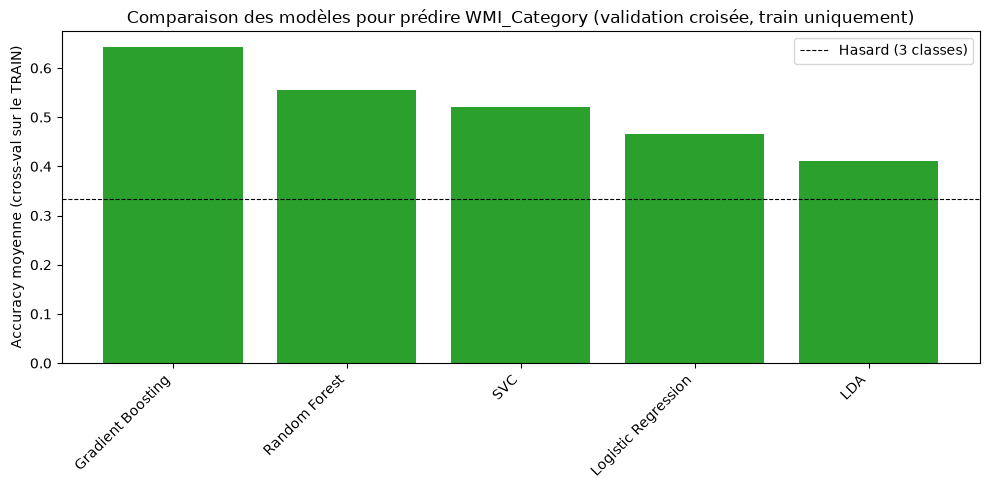

In [ ]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if acc >= 1/3 else "#d62728" for acc in results_df["Accuracy_mean"]]
plt.bar(results_df["Model"], results_df["Accuracy_mean"], color=colors)

# Ligne de référence : accuracy d'un classifieur "au hasard" pour 3 classes équilibrées
plt.axhline(1/3, color="black", linewidth=0.8, linestyle="--", label="Hasard (3 classes)")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy moyenne (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN}_Category (validation croisée, train uniquement)")
plt.legend()
plt.tight_layout()
plt.show()

### Sélection du meilleur modèle et évaluation UNIQUE sur le test

Le modèle est choisi selon le meilleur **sur le train**. On l'entraîne
ensuite une seule fois sur tout le train, puis on l'évalue **une seule fois** sur le test —
la seule métrique qui compte pour juger de la performance réelle hors échantillon.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# Meilleur modèle sélectionné
best_model_name = results_df.iloc[0]["Model"]
final_pipeline = models[best_model_name]

# Données de test
X_test = X_test
y_test_cat = y_test_df["WMI_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": best_model_name,
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(results_df.iloc[0]["Accuracy_mean"], 3),
}])

summary_test

,Modèle retenu,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,Gradient Boosting,0.286,0.262,0.222,0.642


### Visualisation : valeurs prédites vs valeurs réelles TRAIN/TEST

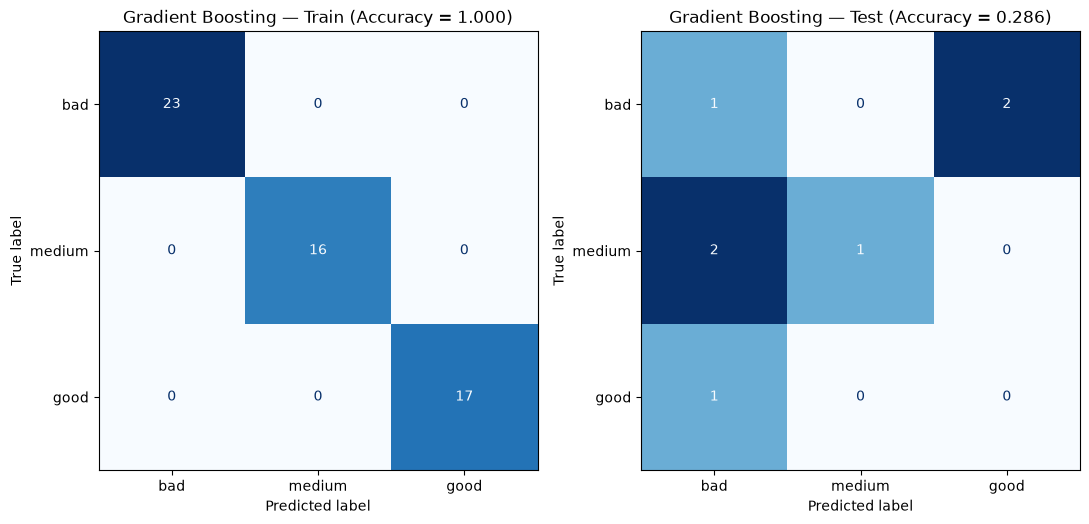

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

y_pred_train = final_pipeline.predict(X_train)
train_accuracy = accuracy_score(y, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_train,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"{best_model_name} — Train (Accuracy = {train_accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    y_pred_test,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"{best_model_name} — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()

### Learning curve du modèle réellement retenu (sur le train)

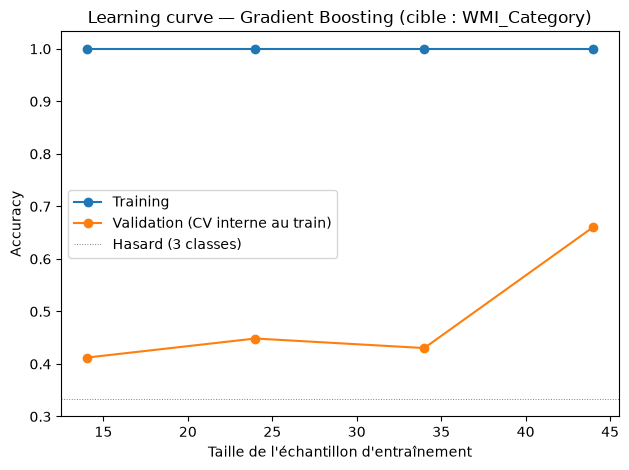

Cible prédite : WMI_Category (bad / medium / good)
Échantillon   : 56 (train) / 7 (test)

Classement des modèles (CV sur le train) :
              Model  Accuracy_mean  Accuracy_std  F1_macro_mean  Balanced_accuracy_mean
  Gradient Boosting          0.642         0.116          0.618                   0.633
      Random Forest          0.556         0.162          0.493                   0.521
                SVC          0.521         0.129          0.448                   0.480
Logistic Regression          0.465         0.108          0.390                   0.430
                LDA          0.411         0.091          0.384                   0.401

Performance du modèle retenu sur le test (jamais vu avant) :
    Modèle retenu  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
Gradient Boosting            0.286            0.262                     0.222                0.642


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — {best_model_name} (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))

## OneVsRestClassifier

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

param_grids = {
    "OneVsRest": (
        OneVsRestClassifier(LogisticRegression(max_iter=1000)),
        {
            "model__estimator__C": [0.01, 0.1, 1, 10],
            "model__estimator__penalty": ["l2"],
            "model__estimator__solver": ["lbfgs"],
        },
    )
}

best_params_summary = []

for name, (estimator, grid) in param_grids.items():
    try:
        imputer
    except NameError:
        imputer = KNNImputer()

    pipeline = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", estimator),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X, y)

    models[name] = grid_search.best_estimator_

    best_params_summary.append({
        "Model": name,
        "Best F1_macro (CV)": round(grid_search.best_score_, 3),
        "Best params": grid_search.best_params_,
    })

    print(
        f"{name} : meilleurs paramètres = "
        f"{grid_search.best_params_} "
        f"(F1_macro = {grid_search.best_score_:.3f})"
    )

best_params_df = (
    pd.DataFrame(best_params_summary)
    .sort_values("Best F1_macro (CV)", ascending=False)
)

best_params_df

OneVsRest : meilleurs paramètres = {'model__estimator__C': 1, 'model__estimator__penalty': 'l2', 'model__estimator__solver': 'lbfgs'} (F1_macro = 0.391)


,Model,Best F1_macro (CV),Best params
0,OneVsRest,0.391,"{'model__estimator__C': 1, 'model__estimator__..."


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

final_pipeline = models['OneVsRest']

# Données de test
X_test = X_test
y_test_cat = y_test_df["WMI_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": 'OneVsRest',
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(results_df.iloc[0]["Accuracy_mean"], 3),
}])

summary_test

,Modèle retenu,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,OneVsRest,0.143,0.083,0.111,0.502


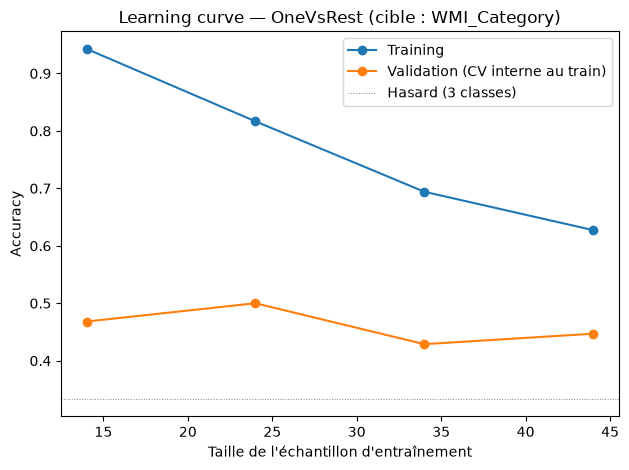

Cible prédite : WMI_Category (bad / medium / good)
Échantillon   : 56 (train) / 7 (test)

Classement des modèles (CV sur le train) :
    Model  Accuracy_mean  Accuracy_std  F1_macro_mean  Balanced_accuracy_mean
OneVsRest          0.502         0.055          0.465                   0.483

Performance du modèle retenu sur le test (jamais vu avant) :
Modèle retenu  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
    OneVsRest            0.143            0.083                     0.111                0.502


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — {'OneVsRest'} (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))